In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gc
from pathlib import Path
from define_data_and_variables import pt_config, data, hash_configs, version


In [2]:
base_dir = Path.cwd()
base_path = base_dir / ".." / ".." / ".." / ".." / "data"
data_name = rf"$A_{{{data["dn"][:3]}}}$"
true_sample = np.load(base_path / data["dn"] / version / "true_sample.npy")
int_version = int(version)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
c14_label = r"$^{230}$Th" if "d18o" in data["dn"] else r"$^{14}$C"
measure = "mm" if "d18o" in data["dn"] else "cm"


In [3]:
base_dir = Path.cwd()
sp_dir = base_dir / f"output/{data['dn']}/{version}"
np.random.seed(pt_config['hmcc']['sd'])
sp = np.random.lognormal(mean = data["pm"], sigma = data["ps"], size = (pt_config["nt"], data["N"]))
pt_config["hmcc"]["sp"] = np.ascontiguousarray(sp)

pt_hash = hash_configs(pt_config, data)
output_dir = sp_dir / f"{pt_hash}"

hmc_config = pt_config["hmcc"]

In [4]:
colors = plt.cm.viridis(np.linspace(0, 1, pt_config["nt"]))

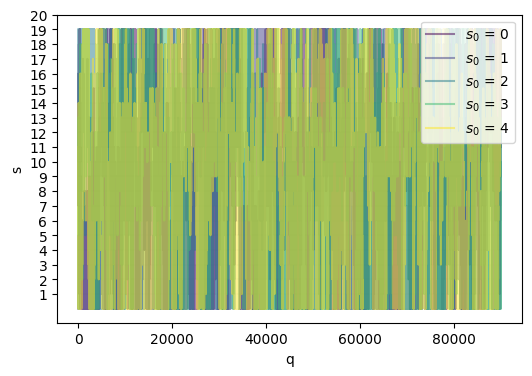

In [ ]:
import matplotlib as mpl
cutout = 10000
num_starts = 5
temp_indices = np.load(output_dir / "temp_indices.npy", mmap_mode = "r")[:, cutout:]
norm = mpl.colors.Normalize(vmin=min(pt_config['bs'][0:num_starts]), vmax=max(pt_config['bs'][0:num_starts]))
cmap = plt.cm.viridis
plt.figure(figsize=(6, 4))
xmin = 0
xmax = len(temp_indices[0, :])
plt.hlines(np.linspace(0, pt_config["nt"] - 1, pt_config["nt"]), linestyle = '--', color = "grey", linewidth = 0.1,  xmin = xmin, xmax = xmax)
for i in range(0, num_starts):
    temp_indices_i = (temp_indices == i).argmax(axis=0)
    plt.plot(np.arange(xmin, xmax, 1), temp_indices_i[xmin:xmax], label = r"$s_0$" + f" = {i}", color = cmap(norm(pt_config['bs'][i])), alpha = 0.5)  
plt.yticks(np.linspace(1, pt_config["nt"], pt_config["nt"]))
plt.ylabel("s")
plt.xlabel("q")
plt.legend(loc = "upper right")
plt.savefig(f"{output_dir}/index_evolution.jpg")
plt.show()


In [6]:
backwards = False
round_trip = 0
num_temps = len(temp_indices)
num_samples = len(temp_indices[0, :])
print(num_samples)
for chain in range(num_temps):
    for col in range(num_samples):
        if temp_indices[0, col] == chain and backwards:
            round_trip+=1
            backwards = False
        if temp_indices[-1, col] == chain:
            backwards = True
print(90000* round_trip / (num_samples * num_temps))


90001
43.64951500538883


In [6]:
samples = np.load(output_dir / "samples.npy", mmap_mode='r')[:, cutout:, :]

In [ ]:
import arviz as az
print(az.summary(samples))
ess_array = np.array([az.ess(samples[-1, :, i], method = "bulk") for i in range(len(samples[-1, 0, :]))])
print(ess_array)
min_ess = np.min(ess_array)
print(min_ess)

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]    5.683  0.383   4.958    6.384      0.015    0.012     697.0     754.0   
x[1]    3.429  1.038   1.453    5.406      0.019    0.061    8626.0     527.0   
x[2]    3.593  1.145   1.510    5.596      0.037    0.098    3613.0     326.0   
x[3]    6.849  1.942   2.720   10.691      0.103    0.154     360.0     240.0   
x[4]    4.362  2.038   0.866    8.083      0.105    0.145     734.0     411.0   
x[5]    6.673  2.501   1.566   10.254      0.223    0.134     135.0     458.0   
x[6]    5.006  2.310   1.200    9.116      0.065    0.126    6393.0     628.0   
x[7]    4.140  2.579   0.744    9.103      0.224    0.180     158.0     427.0   
x[8]    6.231  2.946   1.196   11.467      0.082    0.109     619.0     942.0   
x[9]    5.583  3.098   0.879   11.154      0.006    0.050  219264.0    3325.0   
x[10]   6.632  3.519   1.053   13.148      0.157    0.003     496.0    6222.0   
x[11]   5.883  2.798   1.017

In [9]:
energy_values = np.load(output_dir / "energy.npy", mmap_mode='r')[:, cutout:]
d18o_energy_values = np.load(output_dir / "d18o_energy.npy", mmap_mode='r')[:, cutout:]
min_energies = [np.min(energy_values, axis = 1)[i] for i in range(pt_config["nt"])]
min_energy_samples = [samples[i, np.argmin(energy_values, axis = 1)[i], :] for i in range(pt_config["nt"])]
closest_to_true_samples = [samples[i, np.argmin(np.linalg.norm(samples[i, :, :] - true_sample, axis = 1)), :] for i in range(pt_config["nt"])]
print(min_energies)

[np.float64(79.7937939302923), np.float64(82.16636774173125), np.float64(84.25736423201636), np.float64(87.13033473024745), np.float64(86.33424875168022), np.float64(92.51597414831048), np.float64(97.3276715479635), np.float64(100.42409569654218), np.float64(103.78305730790605), np.float64(109.44841014291777), np.float64(113.48809215283781), np.float64(121.04117716378249), np.float64(129.19974823279657), np.float64(133.40754345212585), np.float64(142.60620789522187), np.float64(157.3482275525146), np.float64(169.77752858628355), np.float64(185.6771996280238), np.float64(201.50812921648492), np.float64(225.94892374671747)]


In [ ]:
for i in range(0, pt_config["nt"] - 1):
    temp_indices_i = (temp_indices == i).argmax(axis=0)
    print(np.min(temp_indices_i))
    rej_indices = np.where((np.diff(temp_indices_i) == 0) & (temp_indices_i[:-1] != pt_config["nt"] - 1))[0]
    print(rej_indices)
    rej = 0
    for j in range(len(rej_indices)):
        rej+= 1 - np.min([1, np.exp((pt_config["bs"][temp_indices_i[rej_indices][j] + 1] - pt_config["bs"][temp_indices_i[rej_indices][j]]) * (d18o_energy_values[temp_indices_i[rej_indices][j] + 1, rej_indices][j] - d18o_energy_values[temp_indices_i[rej_indices][j], rej_indices][j]))])
    print(rej / pt_config["hmcc"]["ns"])

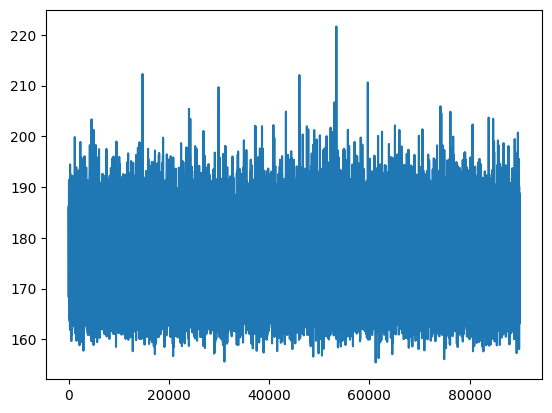

In [10]:
plt.figure()
plt.plot(d18o_energy_values[-1])
plt.show()

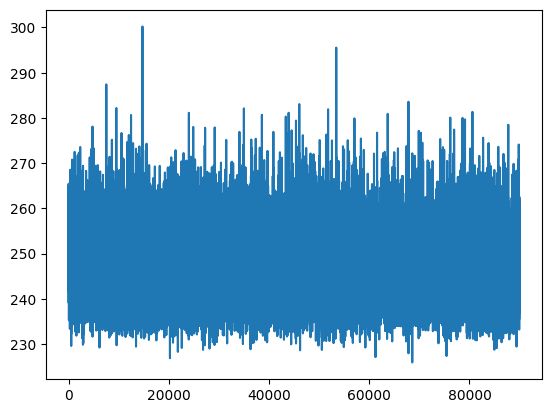

In [11]:
plt.figure()
chain = -1
plt.plot(energy_values[chain] - (pt_config["bs"][chain] - 1) * d18o_energy_values[chain])
plt.show()

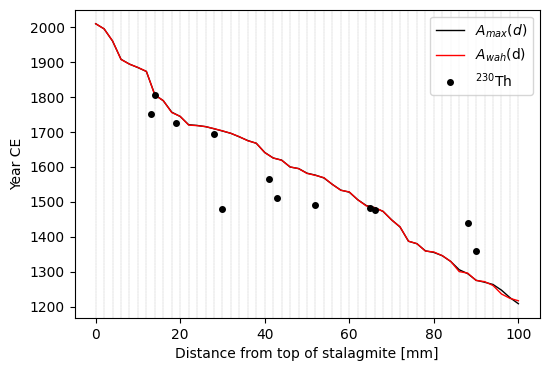

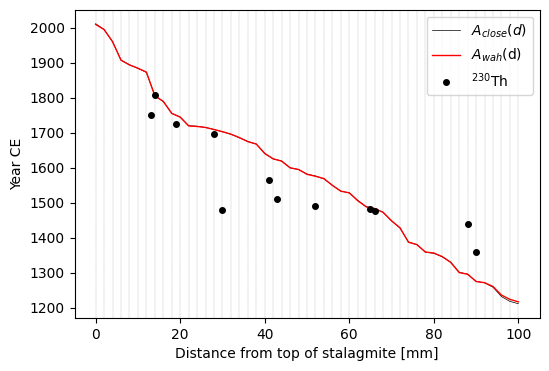

In [13]:
chain = -1
fig, ax = plt.subplots(figsize=(6, 4))
plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([0], np.cumsum(min_energy_samples[chain]))), color = "black", alpha = 1, linewidth = 1, label = r"$A_{max}(d)$")
ax.plot(data["cs"], true_ages, color = "red", linewidth=1, alpha = 1, label = data_name + "(d)")
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.legend()
plt.savefig(f"{output_dir}/max_prob_sol.jpg")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain]))), color = "black", alpha = 1, linewidth = 0.5, label = r"$A_{close}(d)$")
ax.plot(data["cs"], true_ages, color = "red", linewidth=1, alpha = 1, label = data_name + "(d)")
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.legend()
plt.savefig(f"{output_dir}/close_prob_sol.jpg")
plt.show()

In [13]:
index = 17
interesting_depth = index * data["dc"]

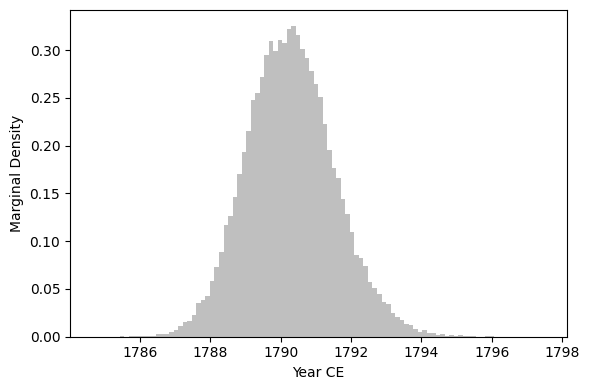

In [17]:
CV_values = data["th"] - data["dc"] * np.sum(samples[-1, :, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density = True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
plt.tight_layout()
# plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

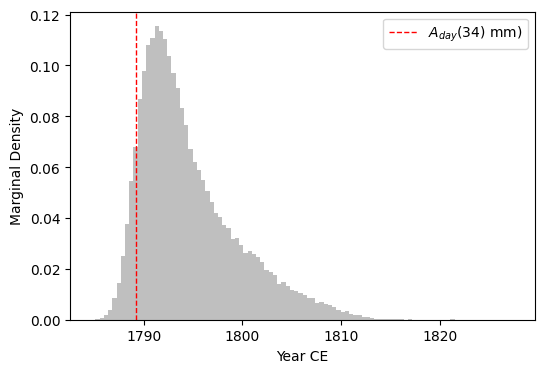

In [ ]:
index2 = 17
CV_values = data["th"] - data["dc"] * np.sum(samples[0, :, :index2], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density = True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index2], color="red", linestyle='--', linewidth = 1, label = data_name + f"({int(index2 *data["dc"])}) " + measure + ")")
plt.legend()
plt.savefig(f"{output_dir}/highT_samples_along_depth_{int(index2 *data["dc"])}.jpg")
plt.show()

c:\Users\hanna\Desktop\PhD\Bacon\bacon_venv\Lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


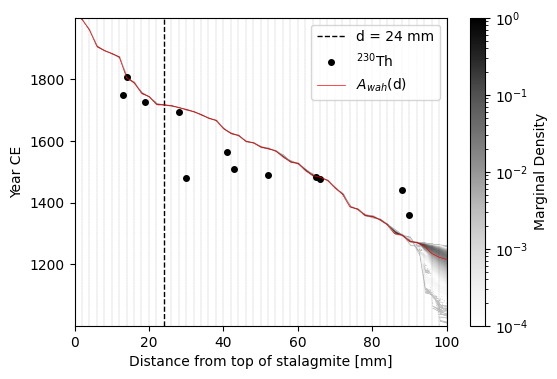

28917

In [ ]:
from matplotlib import colors

X = samples[-1, :, :].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} " + measure)
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
ax.plot(data["cs"], true_ages, color = "red", linewidth=0.5, alpha = 1, label = data_name + "(d)")
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    norm=colors.LogNorm(1e-4, 1)
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/resampled_no_mean.jpg")
plt.show()

del A, C
gc.collect()


c:\Users\hanna\Desktop\PhD\Bacon\bacon_venv\Lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


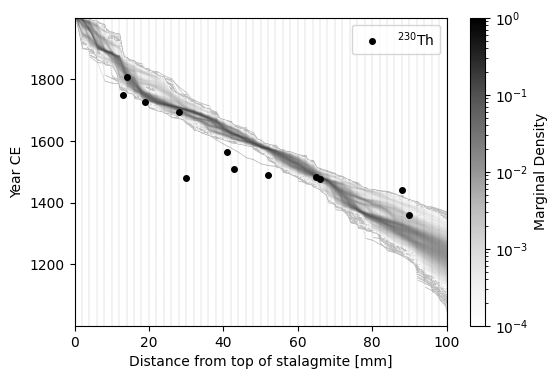

16585

In [ ]:
from matplotlib import colors

X = samples[7, ::5, :].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
# ax.plot(data["cs"], true_ages, color = "red", linewidth=0.5, alpha = 1, label = data_name + "(d)")
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    norm=colors.LogNorm(1e-4, 1)
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/sampled_no_mean.jpg")
plt.show()

del A, C
gc.collect()
